# 11. 핵심 모듈 구축: 시각 분석 + 웹 애플리케이션 통합 + 센서 분석 연동

## 목표
1. **시각 분석 모듈**(이미지/결함 feature 추출)을 함수형으로 분리
2. **센서 분석 모듈**(정제/이상치 스코어링)을 독립 모듈화
3. **웹 애플리케이션(API) 통합 구조**를 설계 및 시연
4. 모듈 간 입출력 스키마를 맞춰 재사용 가능한 파이프라인 구축

---

이 노트북은 실제 서비스 코드로 옮기기 쉬운 형태로 작성됩니다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "core_modules"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: C:\MyCursorLab\10_프로젝트
DATA_ROOT exists: True
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\core_modules


## 1) 아키텍처 개요 (모듈 경계 정의)

```text
[Image Input] ---> [Vision Module] ---\
                                      +--> [Fusion Service] --> [Web/API Response]
[Sensor Stream] -> [Sensor Module] ---/
```

- `vision_module`: 이미지 feature 추출, 품질 score 계산
- `sensor_module`: 센서 정제, 이상 점수 계산
- `fusion_service`: 두 모듈 결과를 합쳐 최종 risk score 산출
- `web_layer`: FastAPI/Streamlit에서 호출하는 진입점

In [2]:
# 샘플 데이터 준비 (이미지 1장 + 센서 시계열)
img_path = sorted((DATA_ROOT / "test" / "images").glob("*.jpg"))[0]
img = np.array(Image.open(img_path).convert("L"), dtype=np.float32) / 255.0

rng = np.random.default_rng(2026)
N = 180
t = np.arange(N)

sensor_df = pd.DataFrame({
    "t": t,
    "lux": 900 + 70*np.sin(2*np.pi*t/60) + rng.normal(0, 15, N),
    "temp": 24 + 0.003*t + rng.normal(0, 0.1, N),
    "vibration": 0.05 + np.abs(rng.normal(0, 0.012, N)),
})

# 비정상 구간 주입
sensor_df.loc[120:145, "vibration"] += 0.03
sensor_df.loc[120:145, "lux"] -= 80

print("image:", img_path.name, img.shape)
display(sensor_df.head())

image: l_light_01_missing_hole_04_2_600.jpg (600, 600)


,t,lux,temp,vibration
0,0,888.103163,24.113649,0.074142
1,1,910.925562,24.066271,0.056968
2,2,886.108923,24.112991,0.058775
3,3,942.567765,23.936249,0.053213
4,4,938.045986,24.087309,0.062373


## 2) Vision Module (시각 분석 모듈)

역할:
- 이미지에서 해석 가능한 feature 추출
- 결함 가능성에 대한 `vision_risk_score` 계산

In [3]:
class VisionModule:
    def __init__(self, edge_thr=0.08):
        self.edge_thr = edge_thr

    def extract_features(self, gray_img: np.ndarray) -> dict:
        mean = float(gray_img.mean())
        std = float(gray_img.std())
        p10, p50, p90 = np.percentile(gray_img, [10, 50, 90])

        gx = np.diff(gray_img, axis=1)
        gy = np.diff(gray_img, axis=0)
        grad_energy = float((gx**2).mean() + (gy**2).mean())
        edge_ratio = float((np.abs(gx) > self.edge_thr).mean())

        return {
            "img_mean": mean,
            "img_std": std,
            "img_p10": float(p10),
            "img_p50": float(p50),
            "img_p90": float(p90),
            "grad_energy": grad_energy,
            "edge_ratio": edge_ratio,
        }

    def predict_risk(self, features: dict) -> float:
        # 실무에서는 학습된 모델 점수 사용; 여기서는 rule-based 데모
        score = (
            0.25 * min(1.0, features["grad_energy"] / 0.03)
            + 0.35 * min(1.0, features["edge_ratio"] / 0.25)
            + 0.40 * min(1.0, abs(features["img_mean"] - 0.5) / 0.35)
        )
        return float(np.clip(score, 0.0, 1.0))

    def run(self, gray_img: np.ndarray) -> dict:
        feats = self.extract_features(gray_img)
        risk = self.predict_risk(feats)
        return {
            "vision_features": feats,
            "vision_risk_score": risk,
        }

vision_module = VisionModule()
vision_out = vision_module.run(img)
print("vision_risk_score:", round(vision_out["vision_risk_score"], 4))
display(pd.DataFrame([vision_out["vision_features"]]))

vision_risk_score: 0.2837


,img_mean,img_std,img_p10,img_p50,img_p90,grad_energy,edge_ratio
0,0.376578,0.137701,0.239216,0.341176,0.592157,0.005021,0.072031


## 3) Sensor Module (센서 데이터 분석 모듈)

역할:
- 결측/이상치 정제
- 파생 feature 생성
- 센서 기반 `sensor_risk_score` 계산

In [4]:
class SensorModule:
    def __init__(self, rolling_window=12):
        self.rolling_window = rolling_window

    @staticmethod
    def _iqr_clip(s: pd.Series, k=1.5):
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        return s.clip(lo, hi), float(lo), float(hi)

    def clean(self, df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
        x = df.copy()
        log = {}

        for c in ["lux", "temp", "vibration"]:
            x[c] = x[c].interpolate().bfill().ffill()
            x[c], lo, hi = self._iqr_clip(x[c], k=1.5)
            log[c] = {"clip_low": lo, "clip_high": hi}

        return x, log

    def feature_engineering(self, df: pd.DataFrame) -> pd.DataFrame:
        x = df.copy()
        w = self.rolling_window
        for c in ["lux", "temp", "vibration"]:
            x[f"{c}_roll_mean"] = x[c].rolling(w, min_periods=1).mean()
            x[f"{c}_roll_std"] = x[c].rolling(w, min_periods=1).std().fillna(0)
            x[f"{c}_diff1"] = x[c].diff().fillna(0)
            x[f"{c}_z"] = (x[c] - x[c].mean()) / (x[c].std() + 1e-9)

        x["lux_vib_ratio"] = x["lux"] / (x["vibration"] + 1e-6)
        return x

    def predict_risk(self, feat_df: pd.DataFrame) -> float:
        # 최신 시점 기준 스코어
        last = feat_df.iloc[-1]
        score = (
            0.45 * min(1.0, abs(last["vibration_z"]) / 3.0)
            + 0.30 * min(1.0, abs(last["lux_z"]) / 3.0)
            + 0.25 * min(1.0, abs(last["temp_z"]) / 3.0)
        )
        return float(np.clip(score, 0.0, 1.0))

    def run(self, df: pd.DataFrame) -> dict:
        clean_df, clean_log = self.clean(df)
        feat_df = self.feature_engineering(clean_df)
        risk = self.predict_risk(feat_df)

        summary_feats = feat_df.iloc[-1][[
            "lux", "temp", "vibration",
            "lux_z", "temp_z", "vibration_z",
            "lux_vib_ratio",
        ]].to_dict()

        return {
            "sensor_clean_log": clean_log,
            "sensor_features_last": {k: float(v) for k, v in summary_feats.items()},
            "sensor_risk_score": risk,
            "sensor_feature_table": feat_df,
        }

sensor_module = SensorModule(rolling_window=12)
sensor_out = sensor_module.run(sensor_df)
print("sensor_risk_score:", round(sensor_out["sensor_risk_score"], 4))
display(pd.DataFrame([sensor_out["sensor_features_last"]]))

sensor_risk_score: 0.2799


,lux,temp,vibration,lux_z,temp_z,vibration_z,lux_vib_ratio
0,921.524362,24.440289,0.052912,0.675926,0.925048,-0.901216,17415.835024


## 4) Fusion Service (모듈 통합 계층)

역할:
- vision/sensor 결과 결합
- 최종 risk score 및 운영 레벨 판정

In [5]:
class FusionService:
    def __init__(self, w_vision=0.6, w_sensor=0.4):
        self.w_vision = w_vision
        self.w_sensor = w_sensor

    @staticmethod
    def risk_level(score: float) -> str:
        if score >= 0.75:
            return "HIGH"
        if score >= 0.45:
            return "MEDIUM"
        return "LOW"

    def run(self, vision_out: dict, sensor_out: dict) -> dict:
        v = vision_out["vision_risk_score"]
        s = sensor_out["sensor_risk_score"]
        fused = self.w_vision * v + self.w_sensor * s

        return {
            "vision_risk_score": float(v),
            "sensor_risk_score": float(s),
            "fused_risk_score": float(np.clip(fused, 0, 1)),
            "risk_level": self.risk_level(float(fused)),
            "vision_features": vision_out["vision_features"],
            "sensor_features_last": sensor_out["sensor_features_last"],
        }

fusion_service = FusionService(w_vision=0.6, w_sensor=0.4)
fusion_out = fusion_service.run(vision_out, sensor_out)
print(json.dumps(fusion_out, indent=2, ensure_ascii=False))

{
  "vision_risk_score": 0.2837394305190263,
  "sensor_risk_score": 0.2798622945379689,
  "fused_risk_score": 0.2821885761266033,
  "risk_level": "LOW",
  "vision_features": {
    "img_mean": 0.3765783905982971,
    "img_std": 0.1377011388540268,
    "img_p10": 0.239215686917305,
    "img_p50": 0.34117648005485535,
    "img_p90": 0.5921568870544434,
    "grad_energy": 0.005021104123443365,
    "edge_ratio": 0.07203116304952699
  },
  "sensor_features_last": {
    "lux": 921.5243618762051,
    "temp": 24.44028903355116,
    "vibration": 0.05291201626313086,
    "lux_z": 0.6759259330637842,
    "temp_z": 0.9250479153928014,
    "vibration_z": -0.90121583299238,
    "lux_vib_ratio": 17415.83502428895
  }
}


,module,score
0,vision,0.283739
1,sensor,0.279862
2,fused,0.282189


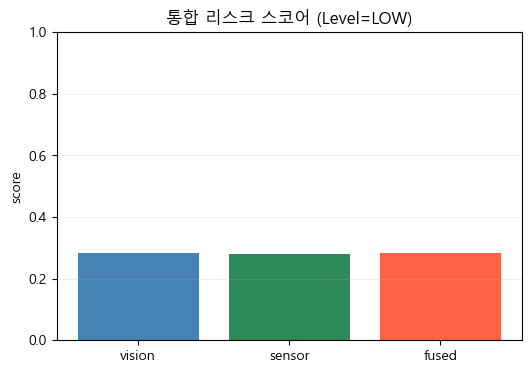

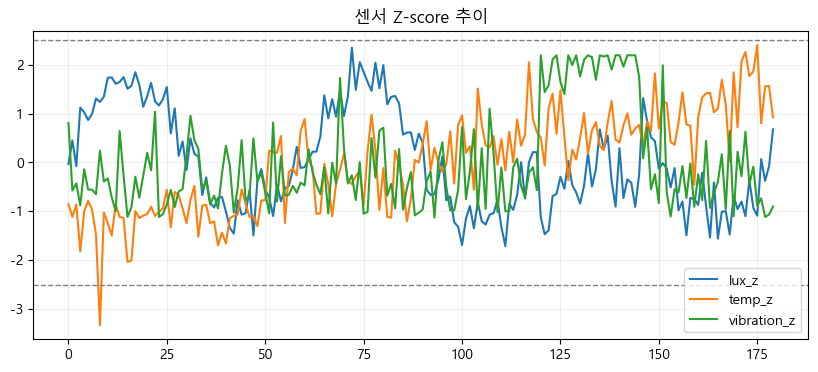

In [6]:
# 통합 결과 시각화
scores = pd.DataFrame([
    {"module": "vision", "score": fusion_out["vision_risk_score"]},
    {"module": "sensor", "score": fusion_out["sensor_risk_score"]},
    {"module": "fused", "score": fusion_out["fused_risk_score"]},
])

display(scores)

plt.figure(figsize=(6, 4))
plt.bar(scores["module"], scores["score"], color=["steelblue", "seagreen", "tomato"])
plt.ylim(0, 1.0)
plt.title(f"통합 리스크 스코어 (Level={fusion_out['risk_level']})")
plt.ylabel("score")
plt.grid(axis="y", alpha=0.2)
plt.show()

# 센서 시계열 일부도 같이 확인
feat_df = sensor_out["sensor_feature_table"]
plt.figure(figsize=(10, 4))
plt.plot(feat_df["t"], feat_df["lux_z"], label="lux_z")
plt.plot(feat_df["t"], feat_df["temp_z"], label="temp_z")
plt.plot(feat_df["t"], feat_df["vibration_z"], label="vibration_z")
plt.axhline(2.5, color="gray", linestyle="--", linewidth=1)
plt.axhline(-2.5, color="gray", linestyle="--", linewidth=1)
plt.legend()
plt.title("센서 Z-score 추이")
plt.grid(alpha=0.2)
plt.show()

## 5) 웹 애플리케이션 통합 (FastAPI 예시)

아래 코드는 실제 `app.py`에 옮기면 되는 최소 통합 예시입니다.
(노트북에서는 참고용 코드로 제시)

```python
from fastapi import FastAPI
import numpy as np
import pandas as pd

app = FastAPI()
vision_module = VisionModule()
sensor_module = SensorModule()
fusion_service = FusionService()

@app.post("/analyze")
def analyze(payload: dict):
    # payload["image"]: 2D grayscale list (0~1)
    # payload["sensor"]: list of sensor rows [{t,lux,temp,vibration}, ...]
    gray_img = np.array(payload["image"], dtype=np.float32)
    sensor_df = pd.DataFrame(payload["sensor"])

    vision_out = vision_module.run(gray_img)
    sensor_out = sensor_module.run(sensor_df)
    result = fusion_service.run(vision_out, sensor_out)
    return result
```

### 프론트엔드 연동 포인트
- Streamlit/React에서 이미지 업로드 + 센서 CSV 업로드
- `/analyze` 호출 후 `fused_risk_score`, `risk_level` 시각화
- 결과 로그를 DB 또는 파일에 저장

In [7]:
# 산출물 저장 (디버깅/웹 연동 테스트용)
with open(OUT_DIR / "fusion_result.json", "w", encoding="utf-8") as f:
    json.dump(fusion_out, f, ensure_ascii=False, indent=2)

pd.DataFrame([vision_out["vision_features"]]).to_csv(
    OUT_DIR / "vision_features.csv", index=False, encoding="utf-8-sig"
)

pd.DataFrame([sensor_out["sensor_features_last"]]).to_csv(
    OUT_DIR / "sensor_features_last.csv", index=False, encoding="utf-8-sig"
)

sensor_out["sensor_feature_table"].to_csv(
    OUT_DIR / "sensor_feature_table.csv", index=False, encoding="utf-8-sig"
)

print("저장 완료:")
for fn in [
    "fusion_result.json",
    "vision_features.csv",
    "sensor_features_last.csv",
    "sensor_feature_table.csv",
]:
    print("-", OUT_DIR / fn)

저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\core_modules\fusion_result.json
- C:\MyCursorLab\10_프로젝트\outputs\core_modules\vision_features.csv
- C:\MyCursorLab\10_프로젝트\outputs\core_modules\sensor_features_last.csv
- C:\MyCursorLab\10_프로젝트\outputs\core_modules\sensor_feature_table.csv


## 실습 과제

1. `FusionService` 가중치를 조정해 오탐/미탐 trade-off를 비교하세요.
2. VisionModule에 추가 feature(LBP, GLCM)를 넣고 성능 변화를 확인하세요.
3. SensorModule에 FFT feature를 추가해 진동 이상 감지 민감도를 개선하세요.
4. FastAPI 엔드포인트에 배치 입력(`/analyze_batch`)을 추가해 처리량을 확장하세요.

---

### 한 줄 정리
핵심 모듈을 분리해 두면, 분석 로직은 재사용되고 웹 애플리케이션은 가볍게 통합할 수 있습니다.